# Lab 13

By Niksh Hiremath (U20240158)

## 1. Code

### Importing libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
np.random.seed(0)
tf.random.set_seed(0)

### Loading the MNIST dataset

In [3]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

X_train.shape, X_test.shape, y_train.shape, y_test.shape

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


((60000, 28, 28), (10000, 28, 28), (60000,), (10000,))

### Sample images from the dataset

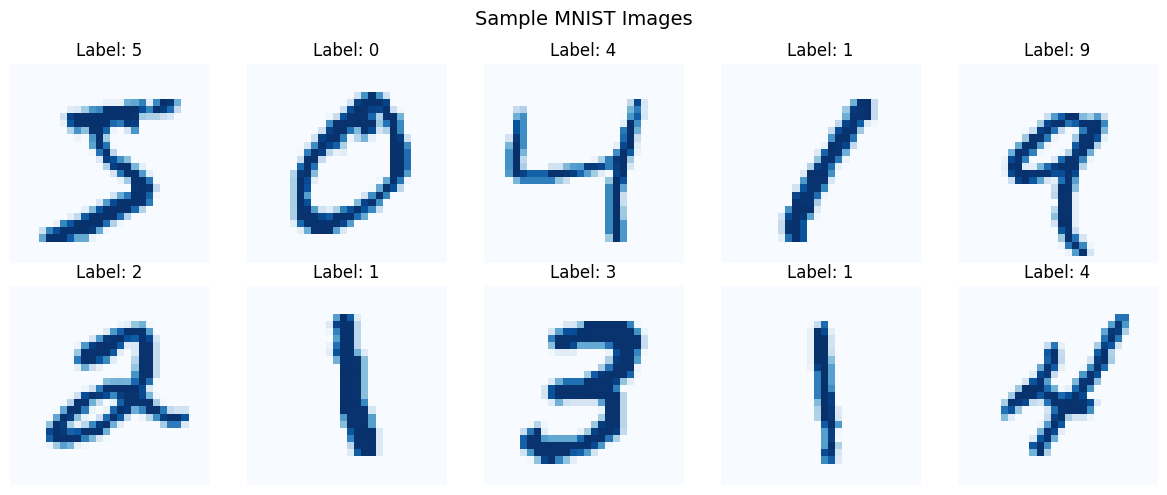

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i], cmap="Blues")
    ax.set_title(f"Label: {y_train[i]}")
    ax.axis("off")

plt.suptitle("Sample MNIST Images", fontsize=14)
plt.tight_layout()
plt.show()

### Preprocessing

In [5]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

X_train = X_train[..., np.newaxis]
X_test = X_test[..., np.newaxis]

print(f"X_train shape after preprocessing: {X_train.shape}")
print(f"X_test  shape after preprocessing: {X_test.shape}")

X_train shape after preprocessing: (60000, 28, 28, 1)
X_test  shape after preprocessing: (10000, 28, 28, 1)


### Defining model hyperparameters

In [6]:
NUM_CLASSES = 10
BATCH_SIZE = 64
EPOCHS = 10
LEARNING_RATE = 0.001

### Building the CNN model

In [7]:
model = keras.Sequential(
    [
        layers.Conv2D(
            32,
            kernel_size=(3, 3),
            activation="relu",
            input_shape=(28, 28, 1),
        ),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dense(NUM_CLASSES, activation="softmax"),
    ]
)

model.summary()

c:\Users\niksh\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

### Compiling and training the model

In [8]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

history = model.fit(
    X_train,
    y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=0.1,
    verbose=1,
)

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 16s 17ms/step - accuracy: 0.9482 - loss: 0.1684 - val_accuracy: 0.9837 - val_loss: 0.0535
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - accuracy: 0.9841 - loss: 0.0513 - val_accuracy: 0.9857 - val_loss: 0.0441
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 17s 20ms/step - accuracy: 0.9900 - loss: 0.0338 - val_accuracy: 0.9873 - val_loss: 0.0407
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 17s 20ms/step - accuracy: 0.9925 - loss: 0.0237 - val_accuracy: 0.9880 - val_loss: 0.0435
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - accuracy: 0.9950 - loss: 0.0163 - val_accuracy: 0.9903 - val_loss: 0.0383
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - accuracy: 0.9956 - loss: 0.0137 - val_accuracy: 0.9907 - val_loss: 0.0410
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 17s 20ms/step - accuracy: 0.9963 - loss: 0.0111 - val_accuracy: 0.9877 - val_loss: 0.0496
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - accuracy: 0.9965 - loss: 0.0100 - 

### Training plots

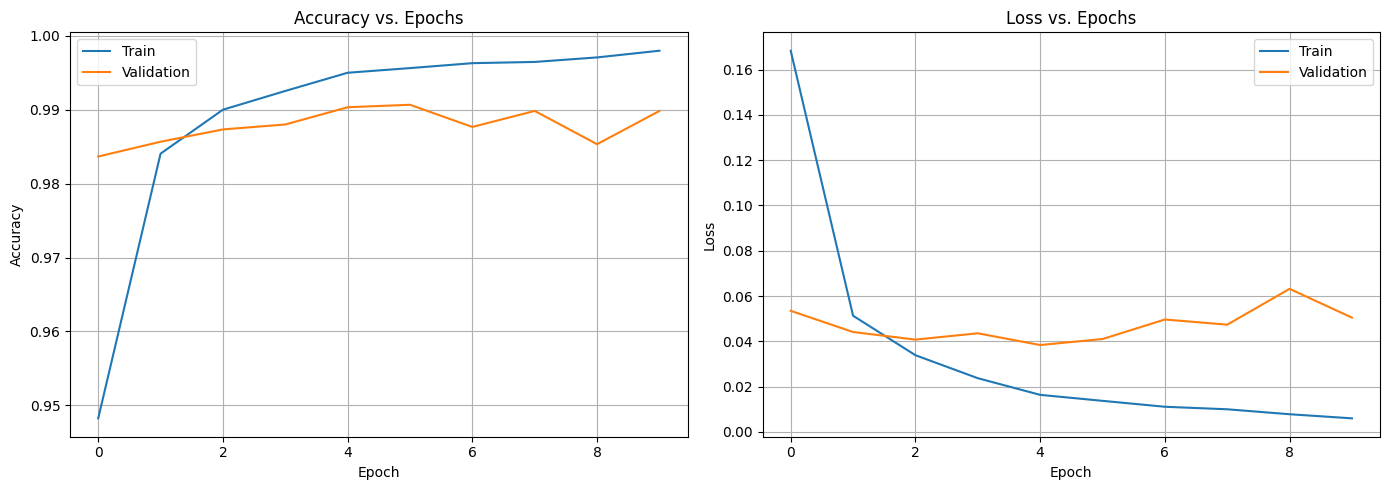

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history["accuracy"], label="Train")
axes[0].plot(history.history["val_accuracy"], label="Validation")
axes[0].set_title("Accuracy vs. Epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid()

axes[1].plot(history.history["loss"], label="Train")
axes[1].plot(history.history["val_loss"], label="Validation")
axes[1].set_title("Loss vs. Epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()

### Performance metrics on test set

In [14]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss:\t\t {test_loss:.4f} ({test_loss:.2%})")
print(f"Test Accuracy:\t {test_acc:.4f} ({test_acc:.2%})")

Test Loss:		 0.0441 (4.41%)
Test Accuracy:	 0.9895 (98.95%)


### Confusion matrix

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


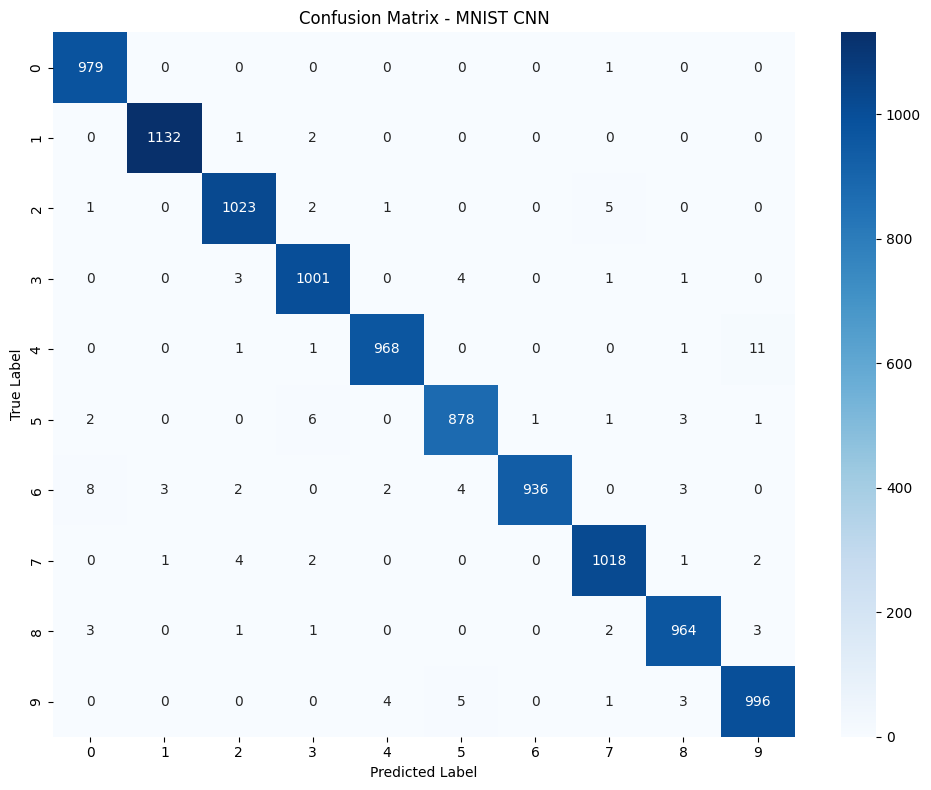

In [17]:
y_pred = np.argmax(model.predict(X_test), axis=1)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=range(NUM_CLASSES),
    yticklabels=range(NUM_CLASSES),
)
plt.title("Confusion Matrix - MNIST CNN")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

### Classification report

In [18]:
report = classification_report(
    y_test,
    y_pred,
    target_names=[str(i) for i in range(NUM_CLASSES)],
)
print(report)

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       1.00      1.00      1.00      1135
           2       0.99      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.98      0.98       892
           6       1.00      0.98      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.98      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



---

## 2. Report

---

### Q1: How many layers in the deep neural network were used for features extraction and how many for features classification?

**Ans:** 

- 4 layers were used for features extraction (Conv2D, MaxPooling2D, Conv2D, MaxPooling2D).

- 3 layers for features classification (Flatten, Dense(128), Dense(10)).

---

### Q2: How many kernels were used to extract features on the MNIST images in the first convolutional layer? What were the size of these kernels? 

**Ans:** 32 kernels of size 3×3 were used in the first convolutional layer. 

---

### Q3: What kind of pooling was done on the data and why?

**Ans:** Max pooling with a 2×2 window was used. It retains the most prominent feature in each region, reduces spatial dimensions to lower computation and introduces translation invariance.

---

### Q4: What were the dimensions of the features set for each layer of the deep CNN? Why were the dimensions reducing in each layer?

**Ans:**

| Layer | Output Shape |
|---|---|
| Input | (28, 28, 1) |
| Conv2D(32, 3×3) | (26, 26, 32) |
| MaxPooling2D(2×2) | (13, 13, 32) |
| Conv2D(64, 3×3) | (11, 11, 64) |
| MaxPooling2D(2×2) | (5, 5, 64) |
| Flatten | (1600,) |
| Dense(128) | (128,) |
| Dense(10) | (10,) |

Dimensions reduce because convolutions (without padding) shrink spatial size by `kernel_size - 1`, and max pooling halves each spatial dimension.

---

### Q5: How are the outputs of CNN (which are numbers) i.e. activation outputs of the last layer converted to probabilities and 10 classes (for the 10 digits)?

**Ans:** The final Dense layer has 10 neurons (one per digit). A **softmax** activation is applied, which exponentiates each output and divides by the sum of all 10 exponentials, converting raw scores into a probability distribution that sums to 1. The predicted class is the index with the highest probability.

---